# Segmentación de Clientes — Corporación FinCrece
### Prueba Técnica — Especialista BI

**Objetivo:** agrupar los 320 clientes en segmentos con comportamiento
financiero similar (K-Means), para explicar el negocio, anticipar
riesgos y apoyar decisiones comerciales.

**Este notebook resuelve el Bloque B2 de la prueba:**
1. Aplicar una metodología de segmentación (K-Means)
2. Justificar variables y tratamiento de datos (nulos, outliers, escalado)
3. Interpretar cada segmento en términos de negocio

> Nota: los datos usados son ficticios, generados para efectos de esta prueba técnica.

In [2]:
# Librerias que vamos a usar en todo el notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# Cargamos el archivo de clientes (hoja especifica)
df = pd.read_excel("clientes_ficticio_1.xlsx", sheet_name="clientes_ficticio")

print("Filas y columnas:", df.shape)
df.head() 

Filas y columnas: (320, 26)


,cliente_id,ciudad,departamento,latitud,longitud,fecha_desembolso,producto_credito,monto_desembolsado,saldo_cartera,dias_mora,...,oferta_comercial,tamano_negocio,saldo_mora_30,tasa_mora_ciudad,Ciudad_asesor,MISMO_CIUDAD,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,CLI_0001,Soacha,Cundinamarca,4595896,-74167459,2023-09-10,Crédito Rotativo,4000000,1962045,0,...,Ampliación de cupo,Pequeña empresa,0,0,Bello,NO,0.0,0.0,23.0,23.0
1,CLI_0002,Medellín,Antioquia,6270002,-75537509,2025-08-21,Crédito Rotativo,500000,413510,45,...,Reestructuración de deuda,Pequeña empresa,413510,1,Soacha,NO,NaN,NaN,NaN,NaN
2,CLI_0003,Rionegro,Antioquia,6182028,-75342309,2024-03-15,Línea Emprendimiento,4000000,2603320,5,...,Plan de alivio de pagos,Microempresa,0,0,Rionegro,SI,NaN,320.0,NaN,NaN
3,CLI_0004,Soacha,Cundinamarca,4634156,-7417244,2025-02-07,Crédito Rotativo,800000,638826,30,...,Reestructuración de deuda,Pequeña empresa,0,0,Cali,NO,NaN,NaN,NaN,NaN
4,CLI_0005,Barranquilla,Atlántico,10906759,-74854059,2026-10-13,Crédito Rotativo,4000000,2308652,0,...,Educación financiera + seguro,Pequeña empresa,0,0,Bucaramanga,NO,NaN,NaN,NaN,NaN


## Variables derivadas

Además de las columnas originales, calculamos dos variables nuevas
que no vienen en el archivo, pero que nos ayudarán más adelante a
**interpretar** los segmentos (no se usan directamente para crear
los grupos, para evitar redundancia con las variables originales):

- **porcentaje_saldo_pendiente**: qué tanto le falta pagar al cliente de su crédito.
- **dias_desde_desembolso**: qué tan viejo es el crédito del cliente.

In [3]:
# porcentaje_saldo_pendiente: 0 = ya pago casi todo, 1 = casi no ha pagado nada
df["porcentaje_saldo_pendiente"] = df["saldo_cartera"] / df["monto_desembolsado"]

# dias_desde_desembolso: que tan viejo es el credito
fecha_mas_reciente = df["fecha_desembolso"].max()
df["dias_desde_desembolso"] = (fecha_mas_reciente - df["fecha_desembolso"]).dt.days

df[["cliente_id", "porcentaje_saldo_pendiente", "dias_desde_desembolso"]].head()

,cliente_id,porcentaje_saldo_pendiente,dias_desde_desembolso
0,CLI_0001,0.490511,1193
1,CLI_0002,0.827020,482
2,CLI_0003,0.650830,1006
3,CLI_0004,0.798532,677
4,CLI_0005,0.577163,64


## Selección de variables para el clustering

Usamos estas 4 variables porque describen el **comportamiento
financiero** del cliente (deuda, atraso, capacidad de pago, tamaño
del crédito), no su identidad (ciudad, sexo, producto). Antes de
usarlas, revisamos si tienen valores vacíos o extremos.

In [4]:
variables_cluster = ["saldo_cartera", "dias_mora",
                     "ingresos_mensuales_estimados", "monto_desembolsado"]

df_cluster = df[variables_cluster]

print("Valores vacios por columna:")
print(df_cluster.isnull().sum())

df_cluster.describe()

Valores vacios por columna:
saldo_cartera                   0
dias_mora                       0
ingresos_mensuales_estimados    0
monto_desembolsado              0
dtype: int64


,saldo_cartera,dias_mora,ingresos_mensuales_estimados,monto_desembolsado
count,3.200000e+02,320.000000,3.200000e+02,3.200000e+02
mean,1.289540e+06,11.906250,2.135625e+06,2.467500e+06
std,1.169795e+06,22.436758,9.121848e+05,1.846680e+06
min,5.807700e+04,0.000000,9.000000e+05,5.000000e+05
25%,4.422778e+05,0.000000,1.300000e+06,8.000000e+05
50%,8.111420e+05,0.000000,2.000000e+06,1.800000e+06
75%,1.741062e+06,15.000000,2.800000e+06,4.000000e+06
max,5.613361e+06,120.000000,3.500000e+06,6.000000e+06


## Escalado de variables

`dias_mora` va de 0 a 120, mientras `ingresos_mensuales_estimados`
va en millones. Sin escalar, el algoritmo daría más peso a la
variable con números más grandes, sin que eso sea correcto. Usamos
`StandardScaler` para dejar todas las variables comparables entre sí.

In [5]:
escalador = StandardScaler()
datos_escalados = escalador.fit_transform(df_cluster)

datos_escalados[:5]

array([[ 0.57579169, -0.53148932, -0.14891436,  0.83116753],
       [-0.75004715,  1.47728921, -0.14891436, -1.06709437],
       [ 1.12484438, -0.3082917 , -0.91750458,  0.83116753],
       [-0.55713404,  0.80769637, -0.14891436, -0.9043862 ],
       [ 0.87255284, -0.53148932,  0.72947447,  0.83116753]])

## ¿Cuántos segmentos crear?

K-Means necesita  cuántos grupos crear.
vamos a probar de 2 a 8 grupos y medimos dos cosas:

- **Inercia**: qué tan compactos quedan los clientes dentro de cada grupo (método del codo)
- **Silhouette score**: qué tan bien separados quedan los grupos entre sí (va de -1 a 1, más alto es mejor)

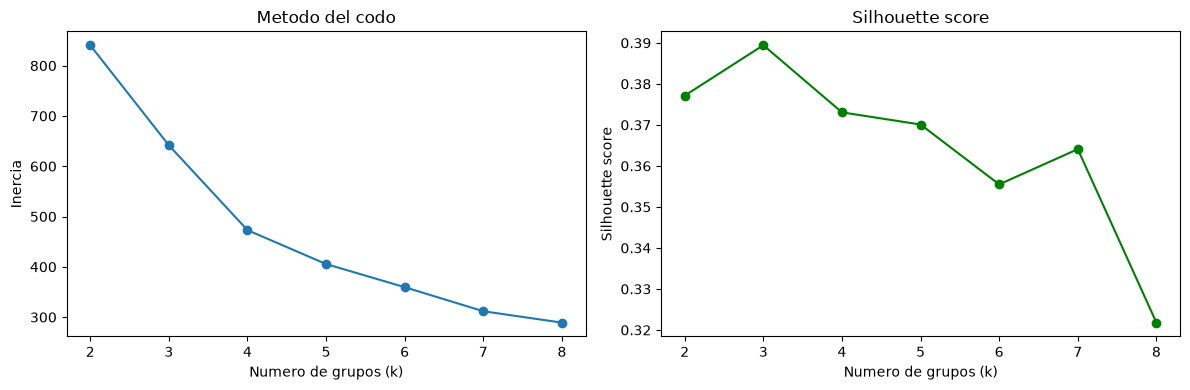

In [6]:
inercias = []
silhouettes = []
opciones_de_grupos = range(2, 9)

for k in opciones_de_grupos:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    grupo_de_cada_cliente = modelo.fit_predict(datos_escalados)
    inercias.append(modelo.inertia_)
    silhouettes.append(silhouette_score(datos_escalados, grupo_de_cada_cliente))

# Graficamos ambas metricas lado a lado
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(opciones_de_grupos, inercias, marker='o')
ax[0].set_title("Metodo del codo")
ax[0].set_xlabel("Numero de grupos (k)")
ax[0].set_ylabel("Inercia")

ax[1].plot(opciones_de_grupos, silhouettes, marker='o', color='green')
ax[1].set_title("Silhouette score")
ax[1].set_xlabel("Numero de grupos (k)")
ax[1].set_ylabel("Silhouette score")

plt.tight_layout()
plt.savefig("outputs_metodo_codo_silhouette.png", dpi=150)
plt.show()

## Aplicación de K-Means (k=4)

Con base en el método del codo y el silhouette score, usamos
4 grupos: buen balance entre compactación de los grupos y
facilidad de interpretación de negocio.

In [7]:
# Entrenamos el modelo final con 4 grupos
modelo_final = KMeans(n_clusters=4, random_state=42, n_init=10)  #### semilla 42  ##### correr 10 veces 
df["segmento"] = modelo_final.fit_predict(datos_escalados)
 
# Cuantos clientes cayeron en cada segmento
df["segmento"].value_counts().sort_index()

segmento
0    135
1     32
2     78
3     75
Name: count, dtype: int64

## Perfil de cada segmento

Ahora calculamos el promedio de cada variable dentro de cada
segmento, para poder describir qué tipo de cliente representa
cada grupo (Punto 3 de la prueba: interpretación de negocio).

In [8]:
# Promedio de cada variable por segmento (incluyendo las derivadas)
columnas_perfil = ["saldo_cartera", "dias_mora", "ingresos_mensuales_estimados",
                    "monto_desembolsado", "porcentaje_saldo_pendiente", "dias_desde_desembolso"]

perfil_segmentos = df.groupby("segmento")[columnas_perfil].mean().round(2)
perfil_segmentos["cantidad_clientes"] = df["segmento"].value_counts().sort_index()

perfil_segmentos

,saldo_cartera,dias_mora,ingresos_mensuales_estimados,monto_desembolsado,porcentaje_saldo_pendiente,dias_desde_desembolso,cantidad_clientes
segmento,,,,,,,
0,771762.41,5.78,1479259.26,1472592.59,0.54,709.03,135
1,849977.34,67.03,2121875.00,1737500.00,0.52,647.66,32
2,2861123.83,7.18,2243589.74,5205128.21,0.57,766.42,78
3,774638.11,4.33,3210666.67,1722666.67,0.50,717.09,75


## Interpretación de negocio de los segmentos

| Segmento | Nombre propuesto | Por qué |
|---|---|---|
| 1 | **Riesgo alto / Mora crítica** | Mora muy por encima del resto (67 días vs 4-7 días en los demás) |
| 0 | **Base estándar / Riesgo bajo-medio** | El grupo más grande (135 clientes), ingresos bajos pero mora controlada — la "base" del negocio |
| 2 | **Alto valor / Ticket grande** | Créditos grandes ($5.2M en promedio), mora controlada — clientes "premium" en tamaño |
| 3 | **Bajo riesgo / Alto potencial** | Ingresos altos ($3.2M), mora mínima (4.3 días) → oportunidad de ofrecerles más productos |

## Visualización de los segmentos

Como tenemos 4 variables (no se pueden graficar todas a la vez
en 2D), mostramos dos vistas: saldo de cartera vs días de mora
(el cruce más relevante para riesgo), y monto desembolsado vs
ingresos (para ver el tamaño del crédito vs capacidad de pago).

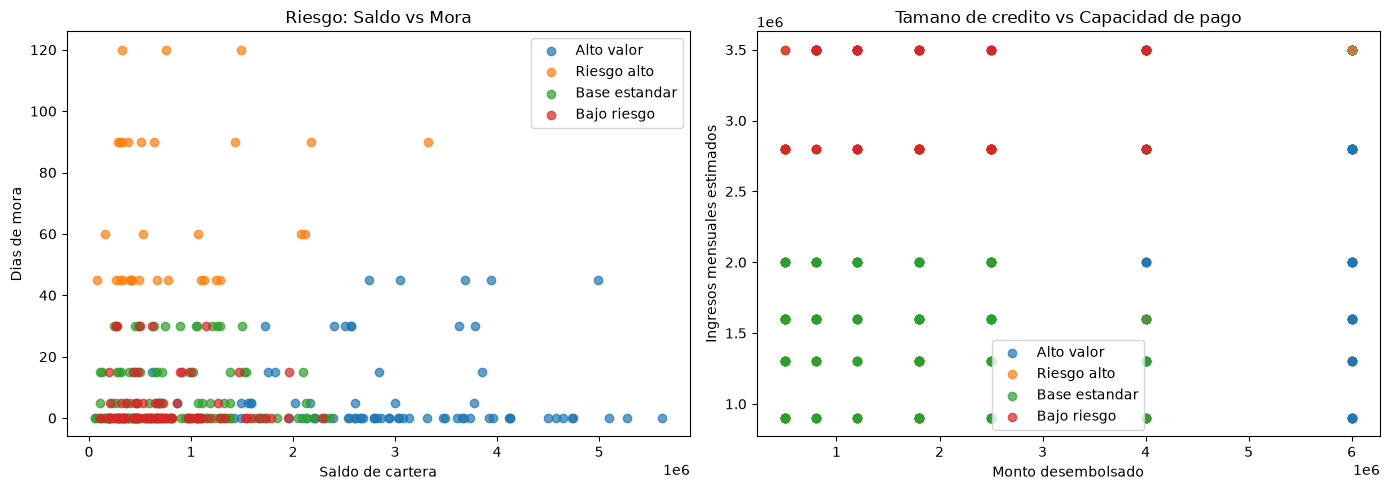

In [9]:
nombres_segmento = {
    1: "Riesgo alto",
    0: "Base estandar",
    2: "Alto valor",
    3: "Bajo riesgo"
}
df["nombre_segmento"] = df["segmento"].map(nombres_segmento)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

for seg in df["segmento"].unique():
    subset = df[df["segmento"] == seg]
    ax[0].scatter(subset["saldo_cartera"], subset["dias_mora"],
                   label=nombres_segmento[seg], alpha=0.7)
    ax[1].scatter(subset["monto_desembolsado"], subset["ingresos_mensuales_estimados"],
                   label=nombres_segmento[seg], alpha=0.7)

ax[0].set_xlabel("Saldo de cartera")
ax[0].set_ylabel("Dias de mora")
ax[0].set_title("Riesgo: Saldo vs Mora")
ax[0].legend()

ax[1].set_xlabel("Monto desembolsado")
ax[1].set_ylabel("Ingresos mensuales estimados")
ax[1].set_title("Tamano de credito vs Capacidad de pago")
ax[1].legend()

plt.tight_layout()
plt.savefig("outputs_segmentos_scatter.png", dpi=150)
plt.show()

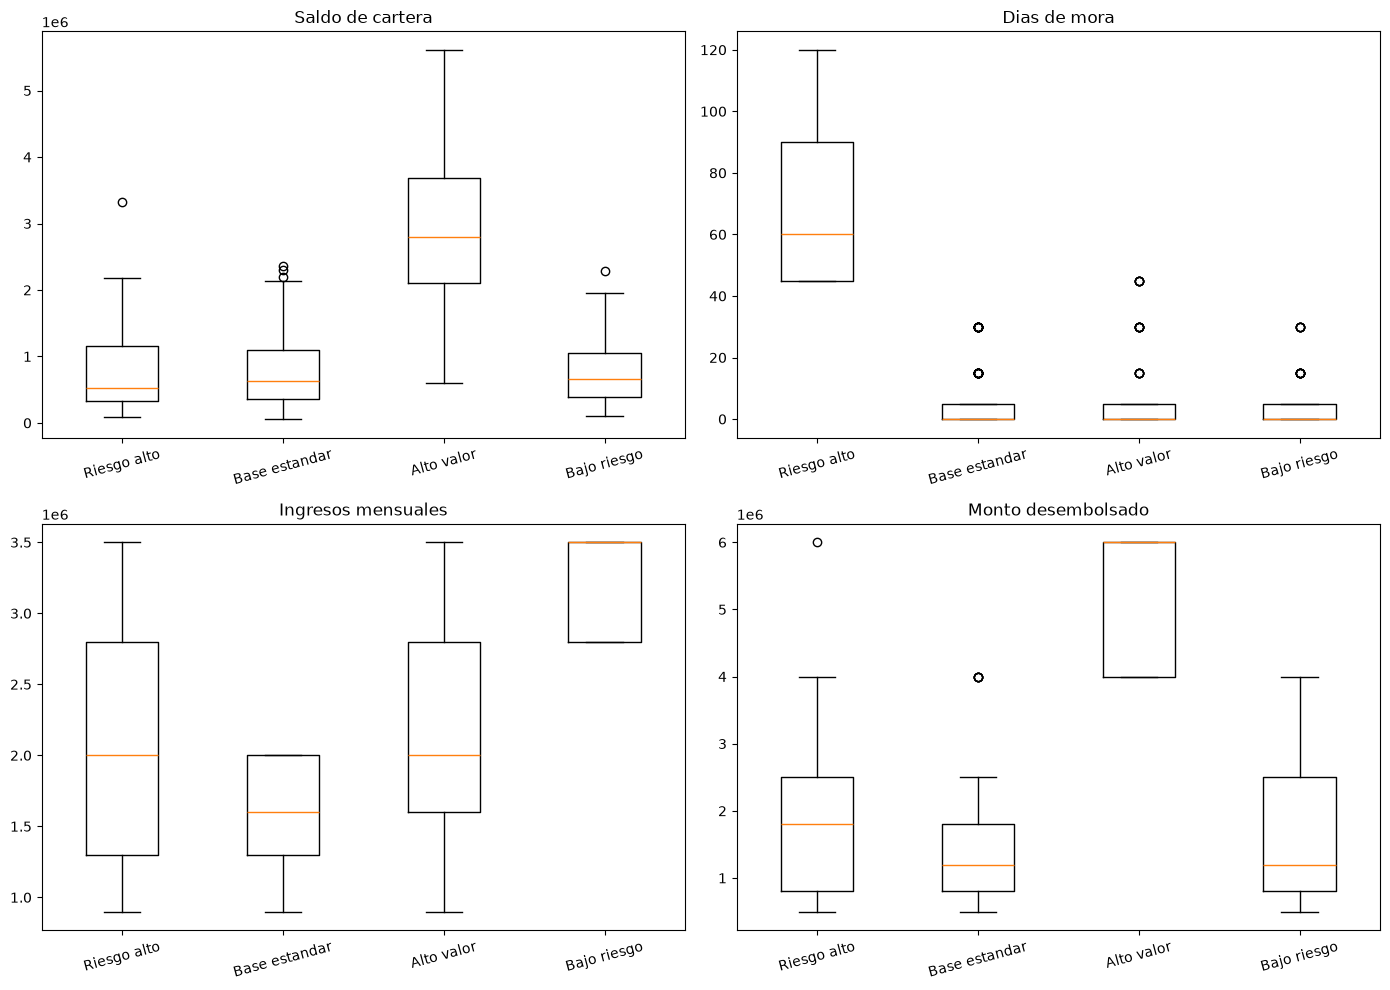

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

orden_segmentos = ["Riesgo alto", "Base estandar", "Alto valor", "Bajo riesgo"]

variables_a_graficar = ["saldo_cartera", "dias_mora", "ingresos_mensuales_estimados", "monto_desembolsado"]
titulos = ["Saldo de cartera", "Dias de mora", "Ingresos mensuales", "Monto desembolsado"]

for ax, var, titulo in zip(axes.flatten(), variables_a_graficar, titulos):
    datos_por_grupo = [df[df["nombre_segmento"] == seg][var] for seg in orden_segmentos]
    ax.boxplot(datos_por_grupo, tick_labels=orden_segmentos)
    ax.set_title(titulo)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig("outputs_segmentos_boxplot.png", dpi=150)
plt.show()

**Conclusion:** los boxplots confirman visualmente la separación de los 4 segmentos.
"Riesgo alto" se distingue por su mora (45-90 días, muy por encima del resto);
"Alto valor" por el tamaño de sus créditos ($4M-$6M); y "Bajo riesgo" por sus
ingresos altos ($2.8M-$3.5M). La poca superposición entre cajas confirma que
el modelo encontró grupos con identidad propia, no solo divisiones artificiales.

---
## Análisis complementario (valor agregado)

### Dendrograma jerárquico de asesores

Este análisis no fue solicitado explícitamente en la prueba, pero
se propone como complemento: con solo 10 asesores, un dendrograma
(clustering jerárquico) permite ver visualmente qué tan parecidos
o distintos son entre sí en su desempeño, y en qué nivel de similitud
se van agrupando — información más rica que solo un ranking (Top 5
del Bloque B1) para decisiones de gestión de equipo.

In [11]:
metricas_asesor = df.groupby("asesor_id_actual").agg(
    cartera_total=("saldo_cartera", "sum"),
    mora_total=("saldo_mora_30", "sum"),
    cantidad_clientes=("cliente_id", "count"),
    mora_promedio_dias=("dias_mora", "mean")
).reset_index()

metricas_asesor["tasa_mora"] = metricas_asesor["mora_total"] / metricas_asesor["cartera_total"]

metricas_asesor

,asesor_id_actual,cartera_total,mora_total,cantidad_clientes,mora_promedio_dias,tasa_mora
0,ASE_001,40119123,5566259,33,15.606061,0.138743
1,ASE_002,28589803,2320328,29,10.344828,0.081159
2,ASE_003,36563588,778816,26,7.692308,0.021300
3,ASE_004,34194405,11436467,34,16.323529,0.334454
4,ASE_005,62061404,10806007,33,17.121212,0.174118
5,ASE_006,34603880,1630097,32,9.531250,0.047107
6,ASE_007,49047844,828791,31,8.548387,0.016898
7,ASE_008,37610933,7913618,37,13.108108,0.210407
8,ASE_009,36035444,2744784,30,13.666667,0.076169
9,ASE_010,53826294,1573302,35,6.000000,0.029229


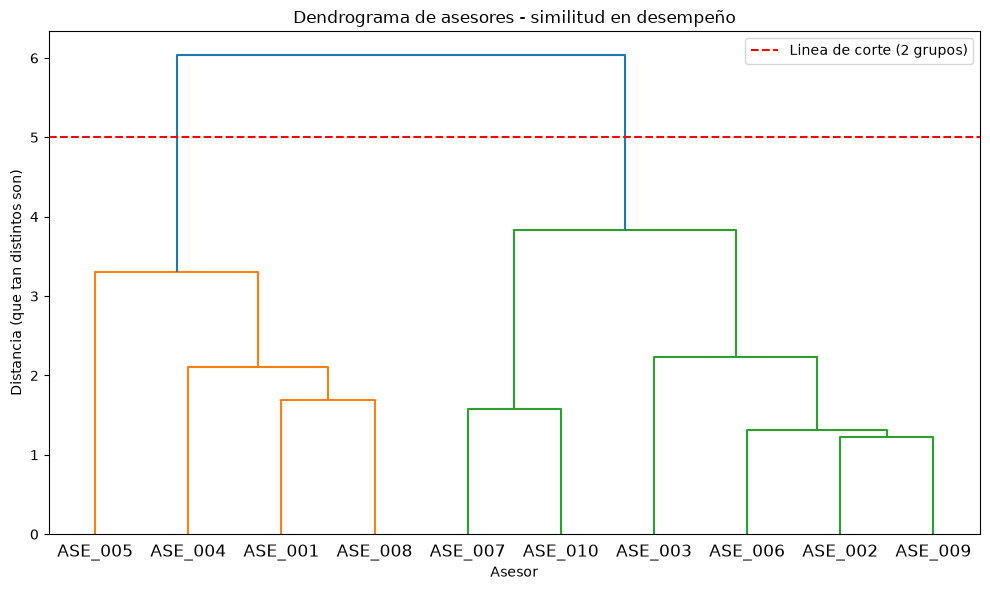

In [12]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler

# Seleccionamos las variables que describen el desempeño del asesor
variables_asesor = ["cartera_total", "tasa_mora", "cantidad_clientes", "mora_promedio_dias"]
datos_asesor = metricas_asesor[variables_asesor]

# Escalamos igual que hicimos con los clientes (mismo motivo: escalas distintas)
escalador_asesor = StandardScaler()
datos_asesor_escalados = escalador_asesor.fit_transform(datos_asesor)

# Calculamos el "linkage" (la estructura jerarquica de agrupamiento)
enlaces = linkage(datos_asesor_escalados, method='ward')

# Graficamos el dendrograma
plt.figure(figsize=(10, 6))
dendrogram(enlaces, labels=metricas_asesor["asesor_id_actual"].values)

# Linea de corte para decidir en cuantos grupos dividimos
plt.axhline(y=5, color='red', linestyle='--', label='Linea de corte (2 grupos)')

plt.title("Dendrograma de asesores - similitud en desempeño")
plt.xlabel("Asesor")
plt.ylabel("Distancia (que tan distintos son)")
plt.legend()
plt.tight_layout()
plt.savefig("outputs_dendrograma_asesores.png", dpi=150)
plt.show()


### Interpretación del dendrograma

La línea de corte en distancia=5 divide a los 10 asesores en 2 familias
claramente diferenciadas por su nivel de riesgo:

| Grupo | Asesores | Tasa de mora |
|---|---|---|
| 🟠 **Riesgo alto** | ASE_004, ASE_008, ASE_001, ASE_005 | 14% - 33% |
| 🟢 **Riesgo controlado** | ASE_002, ASE_009, ASE_006, ASE_003, ASE_007, ASE_010 | 1.7% - 8.1% |

**Hallazgo clave:** cada uno de los 4 asesores del grupo "Riesgo alto"
tiene entre el 14% y el 33% de su propia cartera en mora — una proporción
muy superior a la del grupo "Riesgo controlado" (máximo 8.1%).  

**Recomendación de negocio:** priorizar un plan de acompañamiento o
auditoría de cartera específicamente con el grupo naranja (4 asesores),
antes que una estrategia genérica para los 10.

 **¿Qué es la tasa de mora?** Es el porcentaje de la cartera de cada
> asesor que corresponde a clientes con más de 30 días de atraso en el
> pago.



# Bloque B3 — Georreferenciación y Asignación de Cartera

Este bloque resuelve 3 puntos:
1. Calcular la distancia entre cada cliente y cada asesor
2. Proponer una reasignación óptima que minimice la distancia total,
   respetando la capacidad máxima de cada asesor
3. Visualizar en un mapa la distribución y la propuesta de zonas




In [13]:
# Cargamos asesores desde la misma hoja del archivo Excel
asesores = pd.read_excel("clientes_ficticio_1.xlsx", sheet_name="asesores_ficticio")

clientes_lista = df["cliente_id"].tolist()
asesores_lista = asesores["asesor_id"].tolist()
capacidad_dict = asesores.set_index("asesor_id")["capacidad_maxima_clientes"].to_dict()

print("Clientes:", len(clientes_lista))
print("Asesores:", len(asesores_lista))
print("Capacidad total del sistema:", sum(capacidad_dict.values()))

Clientes: 320
Asesores: 10
Capacidad total del sistema: 310


## Corrección de coordenadas

Se detectaron dos errores de captura de datos en las coordenadas
originales de los clientes:
- **Longitud**: 24 clientes (7.5%) tienen un dígito faltante
- **Latitud**: 38 clientes (12%) tienen un dígito faltante

Ambos se corrigen usando la ubicación del asesor de la misma ciudad
como referencia, para saber cuántos dígitos debería tener cada valor.

In [14]:
# Correccion de longitud: siempre 2 digitos enteros en Colombia (ej. -75.xx)
def corregir_longitud(valor):
    negativo = valor < 0
    texto = str(int(abs(valor)))
    parte_entera = int(texto[:2])
    parte_decimal = int(texto[2:]) / (10 ** len(texto[2:]))
    resultado = parte_entera + parte_decimal
    return -resultado if negativo else resultado

df["longitud_correcta"] = df["longitud"].apply(corregir_longitud)

# Correccion de latitud: la cantidad de digitos enteros varia por ciudad,
# asi que usamos la latitud del asesor de esa ciudad como referencia
referencia_lat_ciudad = asesores.set_index("ciudad_base")["latitud_base"].to_dict()

def corregir_latitud(row):
    valor_crudo = row["latitud"]
    ciudad = row["ciudad"]
    valor_ingenuo = valor_crudo / 1000000

    if ciudad not in referencia_lat_ciudad:
        return valor_ingenuo

    referencia = referencia_lat_ciudad[ciudad]
    if abs(valor_ingenuo - referencia) < 2:
        return valor_ingenuo

    digitos_enteros_esperados = len(str(int(abs(referencia))))
    texto = str(int(abs(valor_crudo)))
    parte_entera = int(texto[:digitos_enteros_esperados])
    parte_decimal = int(texto[digitos_enteros_esperados:]) / (10 ** len(texto[digitos_enteros_esperados:]))
    return parte_entera + parte_decimal

df["latitud_correcta"] = df.apply(corregir_latitud, axis=1)

# Verificacion
corregidos_lon = (abs(df["longitud"]/1000000 - df["longitud_correcta"]) > 1).sum()
corregidos_lat = (abs(df["latitud"]/1000000 - df["latitud_correcta"]) > 0.5).sum()
print(f"Clientes con longitud corregida: {corregidos_lon}")
print(f"Clientes con latitud corregida: {corregidos_lat}")

Clientes con longitud corregida: 24
Clientes con latitud corregida: 39


## Cálculo de distancias (fórmula de Haversine)

Para cada uno de los 320 clientes, calculamos la distancia en
kilómetros hacia cada uno de los 10 asesores, usando la fórmula
de Haversine (considera la curvatura de la Tierra, más precisa
que una distancia euclidiana simple para coordenadas geográficas).

In [15]:
from math import radians, sin, cos, sqrt, atan2

def distancia_haversine(lat1, lon1, lat2, lon2):
    R = 6371  # radio de la Tierra en kilometros
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c

matriz_distancias = pd.DataFrame(index=df["cliente_id"], columns=asesores["asesor_id"])

for i, cliente in df.iterrows():
    for j, asesor in asesores.iterrows():
        dist = distancia_haversine(
            cliente["latitud_correcta"], cliente["longitud_correcta"],
            asesor["latitud_base"], asesor["longitud_base"]
        )
        matriz_distancias.loc[cliente["cliente_id"], asesor["asesor_id"]] = dist

matriz_distancias = matriz_distancias.astype(float)
print("Dimensiones de la matriz:", matriz_distancias.shape)
matriz_distancias.head()

Dimensiones de la matriz: (320, 10)


asesor_id,ASE_001,ASE_002,ASE_003,ASE_004,ASE_005,ASE_006,ASE_007,ASE_008,ASE_009,ASE_010
cliente_id,,,,,,,,,,
CLI_0001,243.764953,247.528824,236.382919,221.259550,15.222819,4.259744,291.796132,713.408451,301.602063,171.409633
CLI_0002,8.211444,7.422495,11.253678,19.263447,238.798146,238.725586,333.759081,529.620627,280.403317,165.522344
CLI_0003,30.580512,30.501241,27.234719,7.101905,217.144408,217.954680,332.464270,536.564429,263.863730,159.772272
CLI_0004,240.197379,243.889337,232.850164,217.582711,12.996532,6.659256,293.205353,709.120316,297.872160,170.371120
CLI_0005,524.145428,516.002161,531.484104,531.224721,696.163502,706.811163,851.056357,9.045523,462.109877,686.479020


## Reasignación óptima de clientes a asesores

Usamos programación lineal (librería PuLP) para resolver el problema
de asignación: minimizar la distancia total recorrida, sujeto a que
cada cliente tenga a lo sumo un asesor, y cada asesor no supere su
capacidad máxima. Se fuerza además que se asignen tantos clientes
como la capacidad total del sistema permita (310 de 320), ya que
sin esta restricción el solver "preferiría" no asignar a nadie
(la distancia total mínima posible es 0).

In [16]:
import pulp

problema = pulp.LpProblem("Asignacion_Optima", pulp.LpMinimize)

x = pulp.LpVariable.dicts("asignar",
                            [(c, a) for c in clientes_lista for a in asesores_lista],
                            cat="Binary")

# Funcion objetivo: minimizar la distancia total
problema += pulp.lpSum(x[(c, a)] * matriz_distancias.loc[c, a]
                        for c in clientes_lista for a in asesores_lista)

# Restriccion: cada cliente, a lo sumo, un asesor
for c in clientes_lista:
    problema += pulp.lpSum(x[(c, a)] for a in asesores_lista) <= 1

# Restriccion: cada asesor no excede su capacidad
for a in asesores_lista:
    problema += pulp.lpSum(x[(c, a)] for c in clientes_lista) <= capacidad_dict[a]

# Restriccion: asignar el maximo posible de clientes (evita la solucion trivial de 0 asignaciones)
capacidad_total = sum(capacidad_dict.values())
maximo_asignable = min(capacidad_total, len(clientes_lista))
problema += pulp.lpSum(x[(c, a)] for c in clientes_lista for a in asesores_lista) == maximo_asignable

problema.solve()
print("Estado de la solucion:", pulp.LpStatus[problema.status])

# Extraemos resultados (uso de > 0.5 en vez de == 1 por precision numerica del solver)
resultados_asignacion = []
for c in clientes_lista:
    asesor_asignado = None
    for a in asesores_lista:
        valor = x[(c, a)].varValue
        if valor is not None and valor > 0.5:
            asesor_asignado = a
            break
    resultados_asignacion.append({"cliente_id": c, "asesor_propuesto": asesor_asignado})

df_resultado = pd.DataFrame(resultados_asignacion)

print("\nClientes sin asignar:", df_resultado["asesor_propuesto"].isna().sum())
print("\nCarga de cada asesor en la propuesta:")
print(df_resultado["asesor_propuesto"].value_counts())

Estado de la solucion: Optimal

Clientes sin asignar: 10

Carga de cada asesor en la propuesta:
asesor_propuesto
ASE_006    40
ASE_008    40
ASE_001    35
ASE_009    35
ASE_010    35
ASE_004    25
ASE_002    25
ASE_003    25
ASE_005    25
ASE_007    25
Name: count, dtype: int64


In [17]:
# Veamos la distancia MINIMA que tenian los 10 clientes excluidos,
# comparada con el resto de clientes que SI se lograron asignar
distancia_minima_por_cliente = matriz_distancias.min(axis=1)

df_check = pd.DataFrame({
    "cliente_id": df["cliente_id"],
    "distancia_minima_posible": distancia_minima_por_cliente.values
})
df_check = df_check.merge(df_resultado, on="cliente_id")

excluidos = df_check[df_check["asesor_propuesto"].isna()]
incluidos = df_check[df_check["asesor_propuesto"].notna()]

print("Distancia MINIMA posible - clientes EXCLUIDOS:")
print(excluidos["distancia_minima_posible"].describe())
print("\nDistancia MINIMA posible - clientes INCLUIDOS:")
print(incluidos["distancia_minima_posible"].describe())

Distancia MINIMA posible - clientes EXCLUIDOS:
count    10.000000
mean      9.244619
std       1.243031
min       7.970979
25%       8.434052
50%       8.787342
75%       9.888323
max      11.547327
Name: distancia_minima_posible, dtype: float64

Distancia MINIMA posible - clientes INCLUIDOS:
count    310.000000
mean       6.640518
std        2.936147
min        0.348438
25%        4.526194
50%        6.625852
75%        8.899344
max       14.007250
Name: distancia_minima_posible, dtype: float64


### Insight: ¿Por qué estos 10 clientes específicos?

Con las coordenadas corregidas, los 10 clientes excluidos de la
asignación óptima muestran una distancia mínima posible apenas
superior al promedio general (9.2 km vs 6.6 km de los incluidos) —
no son casos de aislamiento geográfico extremo, sino el resultado
natural de que la demanda (320 clientes) supera la oferta de
capacidad (310 cupos). Dado que alguien debe quedar fuera, el
algoritmo excluye a quienes, combinados con las restricciones de
capacidad de los demás asesores, representan el menor costo
adicional al total. La causa raíz sigue siendo la brecha
estructural de capacidad, no la ubicación de estos clientes en sí.

## Comparación: asignación actual vs. propuesta óptima

Calculamos la distancia total (suma de las distancias individuales
de cada cliente a su asesor) en dos escenarios: la asignación actual
(la que ya tiene cada cliente hoy) y la propuesta óptima calculada.

In [18]:
# Distancia total con la asignacion ACTUAL
distancia_actual = sum(
    matriz_distancias.loc[row["cliente_id"], row["asesor_id_actual"]]
    for _, row in df.iterrows()
)

# Distancia total con la asignacion PROPUESTA (solo los 310 que si se asignaron)
df_resultado_valido = df_resultado.dropna(subset=["asesor_propuesto"])
distancia_propuesta = sum(
    matriz_distancias.loc[row["cliente_id"], row["asesor_propuesto"]]
    for _, row in df_resultado_valido.iterrows()
)

promedio_actual = distancia_actual / len(df)
promedio_propuesta = distancia_propuesta / len(df_resultado_valido)

print(f"Distancia total ACTUAL: {distancia_actual:,.0f} km")
print(f"Distancia total PROPUESTA: {distancia_propuesta:,.0f} km")
print(f"Reduccion total: {(1 - distancia_propuesta/distancia_actual)*100:.1f}%")
print()
print(f"Distancia PROMEDIO por cliente (actual): {promedio_actual:.1f} km")
print(f"Distancia PROMEDIO por cliente (propuesta): {promedio_propuesta:.1f} km")

Distancia total ACTUAL: 88,463 km
Distancia total PROPUESTA: 9,311 km
Reduccion total: 89.5%

Distancia PROMEDIO por cliente (actual): 276.4 km
Distancia PROMEDIO por cliente (propuesta): 30.0 km


## Visualización en mapa

Mostramos los 320 clientes coloreados según el asesor que la
optimización les propone, junto con la ubicación de los 10 asesores.

In [19]:
import folium

mapa = folium.Map(location=[5.5, -74.5], zoom_start=6, tiles="OpenStreetMap")

colores = ["red", "blue", "green", "purple", "orange",
           "darkred", "cadetblue", "darkgreen", "pink", "gray"]
color_por_asesor = {a: colores[i] for i, a in enumerate(asesores_lista)}

df_con_propuesta = df.merge(df_resultado, on="cliente_id")

for _, cliente in df_con_propuesta.iterrows():
    asesor = cliente["asesor_propuesto"]
    color = color_por_asesor.get(asesor, "black") if pd.notna(asesor) else "black"
    folium.CircleMarker(
        location=[cliente["latitud_correcta"], cliente["longitud_correcta"]],
        radius=3,
        color=color,
        fill=True,
        fill_opacity=0.6,
        popup=f"{cliente['cliente_id']} -> {asesor if pd.notna(asesor) else 'SIN ASIGNAR'}"
    ).add_to(mapa)

for _, asesor in asesores.iterrows():
    folium.Marker(
        location=[asesor["latitud_base"], asesor["longitud_base"]],
        popup=f"{asesor['asesor_id']} - {asesor['nombre_generico']} (capacidad: {asesor['capacidad_maxima_clientes']})",
        icon=folium.Icon(color=color_por_asesor[asesor["asesor_id"]], icon="user", prefix="fa")
    ).add_to(mapa)

mapa.save("mapa_reasignacion_b3.html")
mapa

In [29]:
# Tasa de mora por ciudad y producto, para identificar el producto
# mas problematico en cada ciudad especifica (no solo a nivel nacional)

resumen_ciudad_producto = df.groupby(['ciudad', 'producto_credito']).agg(
    cartera_total=('saldo_cartera', 'sum'),
    mora_total=('saldo_mora_30', 'sum')
)
resumen_ciudad_producto['tasa_mora'] = resumen_ciudad_producto['mora_total'] / resumen_ciudad_producto['cartera_total']

# Para cada ciudad, encontramos el producto con la tasa de mora mas alta
producto_mas_riesgoso_por_ciudad = resumen_ciudad_producto.reset_index().sort_values(
    ['ciudad', 'tasa_mora'], ascending=[True, False]
).groupby('ciudad').first()

print(producto_mas_riesgoso_por_ciudad[['producto_credito', 'tasa_mora']])

                      producto_credito  tasa_mora
ciudad                                           
Barranquilla      Línea Emprendimiento   0.616179
Bello          Microcrédito Individual   0.626224
Bogotá         Microcrédito Individual   0.459854
Bucaramanga       Línea Emprendimiento   0.283331
Cali          Crédito Grupal Solidario   0.480925
Itagüí            Línea Emprendimiento   0.515078
Medellín       Microcrédito Individual   0.197881
Pereira           Línea Emprendimiento   0.141597
Rionegro       Microcrédito Individual   0.104721
Soacha                Crédito Rotativo   0.120143


################### CALCULO DE ESCENARIOS PARA CALI ###################

In [20]:
# Filtramos solo clientes de Cali
clientes_cali = df[df["ciudad"] == "Cali"]

print(f"Total clientes en Cali: {len(clientes_cali)}")

# Escenario Pesimista: TODOS los clientes de Cali
tasa_pesimista = clientes_cali["saldo_mora_30"].sum() / clientes_cali["saldo_cartera"].sum()

# Escenario Medio: solo clientes que NO estan en mora actualmente
cali_al_dia = clientes_cali[clientes_cali["dias_mora"] == 0]
tasa_media = cali_al_dia["saldo_mora_30"].sum() / cali_al_dia["saldo_cartera"].sum() if cali_al_dia["saldo_cartera"].sum() > 0 else 0

# Escenario Optimista: solo segmentos "Bajo riesgo" y "Alto valor" (de B2)
cali_bajo_riesgo = clientes_cali[clientes_cali["nombre_segmento"].isin(["Bajo riesgo", "Alto valor"])]
tasa_optimista = cali_bajo_riesgo["saldo_mora_30"].sum() / cali_bajo_riesgo["saldo_cartera"].sum() if cali_bajo_riesgo["saldo_cartera"].sum() > 0 else 0

print(f"\nTasa de mora - Escenario PESIMISTA (todos los clientes de Cali): {tasa_pesimista:.2%}")
print(f"Tasa de mora - Escenario MEDIO (clientes al dia): {tasa_media:.2%}")
print(f"Tasa de mora - Escenario OPTIMISTA (bajo riesgo + alto valor): {tasa_optimista:.2%}")

print(f"\nClientes al dia en Cali: {len(cali_al_dia)}")
print(f"Clientes bajo riesgo/alto valor en Cali: {len(cali_bajo_riesgo)}")

Total clientes en Cali: 39

Tasa de mora - Escenario PESIMISTA (todos los clientes de Cali): 22.93%
Tasa de mora - Escenario MEDIO (clientes al dia): 0.00%
Tasa de mora - Escenario OPTIMISTA (bajo riesgo + alto valor): 23.41%

Clientes al dia en Cali: 20
Clientes bajo riesgo/alto valor en Cali: 24


In [21]:
# Verificamos la tasa de mora de Cali, desglosada por cada uno de los 4 segmentos
resumen_cali_segmento = clientes_cali.groupby("nombre_segmento").agg(
    cantidad_clientes=("cliente_id", "count"),
    cartera_total=("saldo_cartera", "sum"),
    mora_total=("saldo_mora_30", "sum")
)
resumen_cali_segmento["tasa_mora"] = resumen_cali_segmento["mora_total"] / resumen_cali_segmento["cartera_total"]

print(resumen_cali_segmento)

                 cantidad_clientes  cartera_total  mora_total  tasa_mora
nombre_segmento                                                         
Alto valor                      12       36817263    10668215   0.289761
Bajo riesgo                     12        8758960           0   0.000000
Base estandar                   13        9601269           0   0.000000
Riesgo alto                      2        2572699     2572699   1.000000


In [22]:
# Tasa de mora del segmento "Bajo riesgo" pero calculada con TODOS los clientes
# del negocio (no solo Cali), para tener una muestra mas robusta
bajo_riesgo_general = df[df["nombre_segmento"] == "Bajo riesgo"]
tasa_optimista_final = bajo_riesgo_general["saldo_mora_30"].sum() / bajo_riesgo_general["saldo_cartera"].sum()

base_estandar_general = df[df["nombre_segmento"] == "Base estandar"]
tasa_media_final = base_estandar_general["saldo_mora_30"].sum() / base_estandar_general["saldo_cartera"].sum()

print(f"Tasa OPTIMISTA (Bajo riesgo, todo el negocio, n={len(bajo_riesgo_general)}): {tasa_optimista_final:.2%}")
print(f"Tasa MEDIA (Base estandar, todo el negocio, n={len(base_estandar_general)}): {tasa_media_final:.2%}")
print(f"Tasa PESIMISTA (historico de Cali, n={len(clientes_cali)}): {tasa_pesimista:.2%}")

Tasa OPTIMISTA (Bajo riesgo, todo el negocio, n=75): 0.00%
Tasa MEDIA (Base estandar, todo el negocio, n=135): 0.00%
Tasa PESIMISTA (historico de Cali, n=39): 22.93%


In [23]:
# Escenario Medio: Cali EXCLUYENDO solo el segmento "Riesgo alto"
cali_sin_riesgo_alto = clientes_cali[clientes_cali["nombre_segmento"] != "Riesgo alto"]
tasa_media_final = cali_sin_riesgo_alto["saldo_mora_30"].sum() / cali_sin_riesgo_alto["saldo_cartera"].sum()

print(f"Tasa MEDIA (Cali sin segmento Riesgo alto, n={len(cali_sin_riesgo_alto)}): {tasa_media_final:.2%}")

Tasa MEDIA (Cali sin segmento Riesgo alto, n=37): 19.33%


############################ ANALISIS DE PRIDUCTOS CALI Y RIONEGRO

In [24]:
# Funcion reutilizable para analizar producto + sector economico en una ciudad
def analizar_ciudad(nombre_ciudad, filtro_segmento=None):
    datos = df[df["ciudad"] == nombre_ciudad]
    if filtro_segmento:
        datos = datos[datos["nombre_segmento"].isin(filtro_segmento)]

    resumen = datos.groupby(["producto_credito", "sector_economico"]).agg(
        cantidad_clientes=("cliente_id", "count"),
        cartera_total=("saldo_cartera", "sum"),
        mora_total=("saldo_mora_30", "sum")
    )
    resumen["tasa_mora"] = resumen["mora_total"] / resumen["cartera_total"]
    return resumen.sort_values("cartera_total", ascending=False)

print("=== CALI - Solo segmentos Bajo riesgo y Base estandar ===")
print(analizar_ciudad("Cali", filtro_segmento=["Bajo riesgo", "Base estandar"]))

print("\n=== RIONEGRO - Todos los segmentos (para ver que ya funciona bien) ===")
print(analizar_ciudad("Rionegro"))

=== CALI - Solo segmentos Bajo riesgo y Base estandar ===
                                           cantidad_clientes  cartera_total  \
producto_credito         sector_economico                                     
Crédito Rotativo         Manufactura                       2        2612087   
                         Agroindustria                     2        2518888   
                         Comercio                          3        2183634   
Microcrédito Individual  Comercio                          2        1946159   
Crédito Rotativo         Alimentos                         1        1468409   
Línea Emprendimiento     Servicios                         2        1398492   
Microcrédito Individual  Alimentos                         2        1270337   
Crédito Grupal Solidario Alimentos                         3        1055118   
Línea Emprendimiento     Alimentos                         2        1014541   
Crédito Grupal Solidario Servicios                         1         7809

# Comparamos la carga de mora ANTES (asignacion actual) vs DESPUES (propuesta B3)


In [25]:
# Comparamos la carga de mora ANTES (asignacion actual) vs DESPUES (propuesta B3)

# ANTES: mora actual por asesor (ya la calculamos en el dendrograma)
mora_actual_por_asesor = df.groupby("asesor_id_actual").agg(
    cartera_total=("saldo_cartera", "sum"),
    mora_total=("saldo_mora_30", "sum"),
    cantidad_clientes=("cliente_id", "count")
)
mora_actual_por_asesor["tasa_mora"] = mora_actual_por_asesor["mora_total"] / mora_actual_por_asesor["cartera_total"]

# DESPUES: mora que le "tocaria" a cada asesor con la nueva asignacion de B3
df_con_propuesta = df.merge(df_resultado, on="cliente_id")
df_con_propuesta_validos = df_con_propuesta.dropna(subset=["asesor_propuesto"])

mora_propuesta_por_asesor = df_con_propuesta_validos.groupby("asesor_propuesto").agg(
    cartera_total=("saldo_cartera", "sum"),
    mora_total=("saldo_mora_30", "sum"),
    cantidad_clientes=("cliente_id", "count")
)
mora_propuesta_por_asesor["tasa_mora"] = mora_propuesta_por_asesor["mora_total"] / mora_propuesta_por_asesor["cartera_total"]

# Comparamos lado a lado
comparacion = mora_actual_por_asesor[["tasa_mora", "cantidad_clientes"]].join(
    mora_propuesta_por_asesor[["tasa_mora", "cantidad_clientes"]],
    lsuffix="_actual", rsuffix="_propuesto"
)
print(comparacion)

                  tasa_mora_actual  cantidad_clientes_actual  \
asesor_id_actual                                               
ASE_001                   0.138743                        33   
ASE_002                   0.081159                        29   
ASE_003                   0.021300                        26   
ASE_004                   0.334454                        34   
ASE_005                   0.174118                        33   
ASE_006                   0.047107                        32   
ASE_007                   0.016898                        31   
ASE_008                   0.210407                        37   
ASE_009                   0.076169                        30   
ASE_010                   0.029229                        35   

                  tasa_mora_propuesto  cantidad_clientes_propuesto  
asesor_id_actual                                                    
ASE_001                      0.139047                           35  
ASE_002                 

la optimización de B3 no reduce la mora total del negocio
(el comportamiento histórico de cada cliente no cambia por reasignarle
un asesor). Lo que sí cambia es **cómo se distribuye la carga entre
asesores**. Los asesores previamente más sobrecargados de mora
(ASE_004: 33.5%→4.0%, ASE_005: 17.4%→6.6%) quedan aliviados, pero esa
carga se traslada a otros asesores que antes tenían menos exposición
(ASE_007: 1.7%→18.7%, ASE_010: 2.9%→14.7%).



In [26]:
#############################################

In [27]:
#################################################################### PUNTO DE POWER BI ###################################################

---
## Exportación para Power BI (Bloque B4)

Exportamos una tabla consolidada con los datos originales, el
segmento de cada cliente (resultado de B2), y los rangos de mora
que pide el tablero.

In [28]:
# Eliminamos columnas sueltas que quedaron de formulas de verificacion en Excel
columnas_a_eliminar = ["Unnamed: 22", "Unnamed: 23", "Unnamed: 24", "Unnamed: 25"]
df = df.drop(columns=columnas_a_eliminar, errors="ignore")

# Rangos de mora que pide el tablero (0-30 / 31-60 / 61-90 / +90 dias)
def rango_mora(dias):
    if dias == 0:
        return "Al dia"
    elif dias <= 30:
        return "0-30"
    elif dias <= 60:
        return "31-60"
    elif dias <= 90:
        return "61-90"
    else:
        return "+90"

df["rango_mora"] = df["dias_mora"].apply(rango_mora)

print(df["rango_mora"].value_counts())

# Exportamos la tabla completa y limpia para Power BI
df.to_excel("clientes_para_powerbi.xlsx", index=False)
print("\nArchivo exportado: clientes_para_powerbi.xlsx")

rango_mora
Al dia    187
0-30       96
31-60      25
61-90       9
+90         3
Name: count, dtype: int64

Archivo exportado: clientes_para_powerbi.xlsx
